[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-2/trim-filter-messages.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239435-lesson-4-trim-and-filter-messages)

# Filtering and trimming messages

## 復習

到目前為止，我們對幾件事有了更深入的理解：

* 如何自訂 graph 的 state schema
* 如何定義自訂的 state reducer
* 如何使用多個 graph state schema

## 目標

現在，我們可以開始在 LangGraph 裡把這些概念用在 model 上了！
 
在接下來幾個小節中，我們會逐步打造一個具備長期記憶（long-term memory）的 chatbot。

由於我們的 chatbot 會用到 message，讓我們先多談一點在 graph state 中處理 message 的進階做法。

In [ ]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_openai

In [1]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

我們會使用 [LangSmith](https://docs.langchain.com/langsmith/home) 來做 [tracing](https://docs.langchain.com/langsmith/observability-concepts)。

我們會把記錄寫進一個名為 `langchain-academy` 的 project。

In [3]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## Messages as state

首先，讓我們先定義一些 message。

In [ ]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
messages = [AIMessage(f"所以你說你正在研究海洋哺乳動物？", name="機器人")]
messages.append(HumanMessage(f"是的，我了解鯨魚。但還有什麼其他我應該學習的嗎？", name="Kevin"))

# pretty_print() 會把每則 message 印成好讀的區塊：
# 「Ai Message」= AI 說的話、「Human Message」= 使用者說的話，Name 是我們自己取的名字
for m in messages:
    m.pretty_print()

回想一下，我們可以把它們傳給 chat model。

> 💡 **看懂輸出**：`llm.invoke()` 回傳的不是純文字，而是一個 `AIMessage` 物件。
> 直接輸出物件會看到一大串欄位：`content`（回覆正文）、`response_metadata`（model 資訊）、`usage_metadata`（token 用量）等。
> 平常只需要關心 `content`，用 `pretty_print()` 就能印成好讀的格式。

In [ ]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")

# llm.invoke() 回傳的是一個 AIMessage「物件」，不是純文字。
# 直接讓 notebook 輸出它，會看到 content=... additional_kwargs=... 一大串原始資料，很難讀。
result = llm.invoke(messages)

# 改用 pretty_print()，只印出好讀的回覆內容
result.pretty_print()

# 物件裡還帶著一些有用的欄位，挑重要的看：
print("\n--- 這個 AIMessage 物件的其他欄位 ---")
print(f"型別：{type(result).__name__}")
print(f"token 用量（usage_metadata）：{result.usage_metadata}")

我們可以用 `MessagesState` 在一個簡單的 graph 裡執行我們的 chat model。

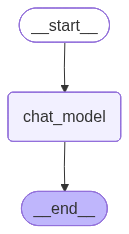

In [8]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node（節點）
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# 建立 graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
output = graph.invoke({'messages': messages})

print(f"執行前送進去 {len(messages)} 則 message，執行後 state 裡有 {len(output['messages'])} 則。")
print("多出來的那 1 則，就是 chat_model 節點產生的 AI 回覆（被 add_messages reducer 附加到清單尾端）。\n")

for m in output['messages']:
    m.pretty_print()

## Reducer

在處理 message 時，一個實際的挑戰是管理長時間進行的對話。

如果不小心處理，長時間進行的對話會造成很高的 token 用量與延遲（latency），因為我們會把一份不斷增長的 message 清單傳給 model。

我們有幾種方式可以處理這個問題。

首先，回想一下我們先前看過的技巧：使用 `RemoveMessage` 搭配 `add_messages` reducer。

下面這個 graph 有兩個節點：

1. `filter`：回傳一串 `RemoveMessage`，`add_messages` reducer 收到後會把對應 id 的 message **從 state 中刪除**，只留最後 2 則
2. `chat_model`：拿刪剩的 message 去呼叫 LLM

兩個節點裡都加了 `print`，執行時可以直接看到 state 在每一步的變化。

In [ ]:
from langchain_core.messages import RemoveMessage

# Nodes（節點）
def filter_messages(state: MessagesState):
    # 刪除除了最近 2 則以外的所有 message
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    print(f"[filter 節點] state 裡目前有 {len(state['messages'])} 則 message")
    print(f"[filter 節點] 回傳 {len(delete_messages)} 個 RemoveMessage（id={[m.id for m in delete_messages]}），reducer 收到後會把它們從 state 刪掉")
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):
    print(f"[chat_model 節點] 經過 filter 後，state 只剩 {len(state['messages'])} 則 message，全部傳給 LLM")
    return {"messages": [llm.invoke(state["messages"])]}

# 建立 graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 帶有開場白（preamble）的 message 清單
messages = [AIMessage("Hi.", name="機器人", id="1")]
messages.append(HumanMessage("Hi.", name="Kevin", id="2"))
messages.append(AIMessage("所以你說你正在研究海洋哺乳動物？", name="機器人", id="3"))
messages.append(HumanMessage("是的，我了解鯨魚。但還有什麼其他我應該學習的嗎？", name="Kevin", id="4"))

print(f"=== 執行前：共 {len(messages)} 則 message ===")
for m in messages:
    print(f"  id={m.id}｜{m.name}：{m.content}")
print()

# 呼叫執行（過程中會先印出兩個節點裡的 print，可以看到 state 一步步的變化）
output = graph.invoke({'messages': messages})

print(f"\n=== 執行後：state 裡剩 {len(output['messages'])} 則 ===")
print("id=1、id=2 被刪掉了；留下 id=3、id=4，最後再加上 LLM 的新回覆：\n")
for m in output['messages']:
    m.pretty_print()

## Filtering messages

如果你不需要、也不想修改 graph state，你可以單純地過濾（filter）要傳給 chat model 的 message。

舉例來說，只要把一份過濾後的清單 `llm.invoke(messages[-1:])` 傳給 model 即可。

In [ ]:
# Node（節點）
def chat_model_node(state: MessagesState):
    print(f"[chat_model 節點] state 裡有 {len(state['messages'])} 則 message，但只把「最後 1 則」傳給 LLM：")
    print(f"[chat_model 節點]   → {state['messages'][-1].content}")
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# 建立 graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

讓我們拿現有的 message 清單，把上面那則 LLM 回覆附加進去，再附加一個後續追問的問題。

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me more about Narwhals!", name="Lance"))

print(f"目前 messages 清單共 {len(messages)} 則：前面的對話 + 剛剛的 LLM 回覆 + 新的追問")

In [ ]:
# 把目前累積的完整對話印出來看看
for m in messages:
    m.pretty_print()

In [ ]:
# 呼叫執行，使用 message filtering
output = graph.invoke({'messages': messages})

print(f"\nstate 裡仍保有全部 {len(output['messages'])} 則 message —— filtering 不會修改 state，")
print("但從上面 [chat_model 節點] 的 print 可以看到，LLM 實際上只收到了最後 1 則。\n")
for m in output['messages']:
    m.pretty_print()

state 裡保有所有的 message。

不過，讓我們看看 LangSmith trace，就能發現這次 model 的呼叫只用到了最後一則 message：

https://smith.langchain.com/public/75aca3ce-ef19-4b92-94be-0178c7a660d9/r

## Trim messages

另一種做法是依據設定的 token 數量來 [trim messages](https://docs.langchain.com/oss/python/langgraph/add-memory#trim-messages)。

這會把 message 歷史限制在指定的 token 數量之內。

filtering 只會在 agent 之間回傳事後（post-hoc）篩選出的 message 子集合，而 trimming 則是限制 chat model 在回應時可以使用的 token 數量。

請看下面的 `trim_messages`。

In [ ]:
from langchain_core.messages import trim_messages

# Node（節點）
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,             # 只保留加起來不超過 100 tokens 的 message
            strategy="last",            # 從「最後面」往前保留（最新的對話最重要）
            token_counter=ChatOpenAI(model="gpt-4o"),  # 用這個 model 的規則計算 token 數
            allow_partial=False,        # 不允許把單一則 message 砍到只剩一半
        )
    print(f"[chat_model 節點] state 裡有 {len(state['messages'])} 則 message，trim 到 100 tokens 以內後，剩 {len(messages)} 則傳給 LLM")
    return {"messages": [llm.invoke(messages)]}

# 建立 graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# 檢視
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# 注意：直接輸出 messages 會看到一大串原始物件，改用 pretty_print 比較好讀
print(f"目前 messages 共 {len(messages)} 則：\n")
for m in messages:
    m.pretty_print()

In [ ]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"告訴我虎鯨住在哪裡！", name="Lance"))

print(f"加入 LLM 回覆和新的追問後，messages 共 {len(messages)} 則：\n")
for m in messages:
    m.pretty_print()

In [ ]:
# trimming 的範例：只保留「從最後面數、加起來不超過 100 tokens」的 message
trimmed = trim_messages(
    messages,
    max_tokens=100,
    strategy="last",
    token_counter=ChatOpenAI(model="gpt-4o"),
    allow_partial=False,
)

print(f"trim 前：{len(messages)} 則 → trim 後：{len(trimmed)} 則")
print("被留下來的是這幾則（前面較舊的都被丟掉了）：\n")
for m in trimmed:
    m.pretty_print()

In [ ]:
# 呼叫執行，在 chat_model_node 中使用 message trimming
# （執行時會印出節點裡的 print，告訴你 trim 前後的 message 數量）
messages_out_trim = graph.invoke({'messages': messages})

In [ ]:
# state 裡仍保有全部 message —— trimming 跟 filtering 一樣，只影響「傳給 LLM 的內容」，不會修改 state
print(f"state 裡共有 {len(messages_out_trim['messages'])} 則 message：\n")
for m in messages_out_trim['messages']:
    m.pretty_print()

讓我們看看 LangSmith trace，了解這次 model 的呼叫情況：

https://smith.langchain.com/public/b153f7e9-f1a5-4d60-8074-f0d7ab5b42ef/r